# Credit Scoring Model — Exploratory Data Analysis (EDA)

**Objective:** Understand the historical credit dataset before building a machine learning model that predicts whether a customer is a **Good (Low Risk)** or **Bad (High Risk)** credit customer.

This notebook covers:
1. Loading the dataset
2. Basic dataset information (shape, columns, data types, summary statistics)
3. Missing values and duplicate records
4. Target variable distribution
5. Numerical feature distributions (histograms)
6. Categorical feature distribution (count plot)
7. Box plots of numerical features vs. the target
8. Correlation heatmap
9. Summary of insights


In [1]:
# Import the libraries needed for this analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# A clean, consistent look for every chart in this notebook
%matplotlib inline
sns.set_style("whitegrid")


## 1. Load the Dataset

In [2]:
# Load the dataset using pandas
df = pd.read_csv("../data/credit_data.csv")

# Display the first 5 rows to get a quick look at the data
df.head()


,Age,Annual_Income,Debt_Amount,Loan_Amount,Number_of_Loans,Payment_History,Credit_Risk
0,53,46644.40,13921.22,4554.64,0,Good,Good
1,38,80412.62,51981.97,14587.83,6,Good,Bad
2,35,76506.28,45456.61,5865.09,4,Poor,Bad
3,27,67391.33,3592.04,40683.50,8,Average,Bad
4,25,65574.98,41160.45,46385.15,6,Average,Bad


## 2. Basic Dataset Information

In [3]:
# Shape of the dataset: (number of rows, number of columns)
print("Dataset shape:", df.shape)

# Names of all columns
print("\nColumn names:", list(df.columns))


Dataset shape: (2010, 7)

Column names: ['Age', 'Annual_Income', 'Debt_Amount', 'Loan_Amount', 'Number_of_Loans', 'Payment_History', 'Credit_Risk']


In [4]:
# Data types of each column and non-null counts
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 2010 entries, 0 to 2009
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Age              2010 non-null   int64  
 1   Annual_Income    1995 non-null   float64
 2   Debt_Amount      1995 non-null   float64
 3   Loan_Amount      2010 non-null   float64
 4   Number_of_Loans  2010 non-null   int64  
 5   Payment_History  1995 non-null   str    
 6   Credit_Risk      2010 non-null   str    
dtypes: float64(3), int64(2), str(2)
memory usage: 110.1 KB


In [5]:
# Statistical summary of the numerical columns
# (count, mean, std, min, 25%, 50%, 75%, max)
df.describe()


,Age,Annual_Income,Debt_Amount,Loan_Amount,Number_of_Loans
count,2010.000000,1995.000000,1995.000000,2010.000000,2010.000000
mean,43.309950,55960.550195,21052.268416,20067.850557,3.998010
std,12.919629,19380.788499,13454.223313,14242.205713,2.539287
min,21.000000,15000.000000,1070.460000,1016.210000,0.000000
25%,32.000000,42373.255000,9849.745000,8384.037500,2.000000
50%,44.000000,56212.180000,18765.370000,16555.445000,4.000000
75%,54.000000,69533.235000,30457.405000,28944.790000,6.000000
max,65.000000,124917.560000,68605.730000,62924.300000,8.000000


## 3. Missing Values and Duplicate Records

In [6]:
# Count the number of missing values in each column
df.isnull().sum()


Age                 0
Annual_Income      15
Debt_Amount        15
Loan_Amount         0
Number_of_Loans     0
Payment_History    15
Credit_Risk         0
dtype: int64

A few columns (`Annual_Income`, `Debt_Amount`, `Payment_History`) contain a small number of missing values. We handle them like this:
- **Numerical** columns → fill missing values with the **median** (robust to outliers).
- **Categorical** columns → fill missing values with the **mode** (the most frequent value).


In [ ]:
for col in ["Annual_Income", "Debt_Amount"]:
    df[col] = df[col].fillna(df[col].median())

# Fill missing categorical values with the most frequent category (mode)
df["Payment_History"] = df["Payment_History"].fillna(df["Payment_History"].mode()[0])

# Confirm that no missing values remain
df.isnull().sum()


Age                0
Annual_Income      0
Debt_Amount        0
Loan_Amount        0
Number_of_Loans    0
Payment_History    0
Credit_Risk        0
dtype: int64

In [8]:
# Check how many duplicate rows exist in the dataset
print("Number of duplicate rows:", df.duplicated().sum())

# Remove duplicate rows and keep the first occurrence
df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)


Number of duplicate rows: 10
Shape after removing duplicates: (2000, 7)


## 4. Target Variable Distribution

Credit_Risk
Good    1300
Bad      700
Name: count, dtype: int64


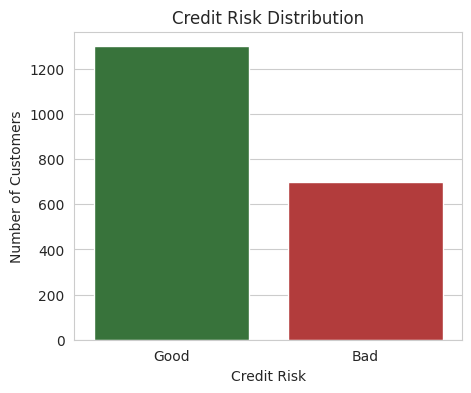

In [9]:
# Count how many customers fall into each credit risk category
print(df["Credit_Risk"].value_counts())

plt.figure(figsize=(5, 4))
sns.countplot(data=df, x="Credit_Risk", hue="Credit_Risk",
              palette={"Good": "#2E7D32", "Bad": "#C62828"}, legend=False)
plt.title("Credit Risk Distribution")
plt.xlabel("Credit Risk")
plt.ylabel("Number of Customers")
plt.savefig("../images/target_distribution.png", dpi=120, bbox_inches="tight")
plt.show()


## 5. Numerical Feature Distributions (Histograms)

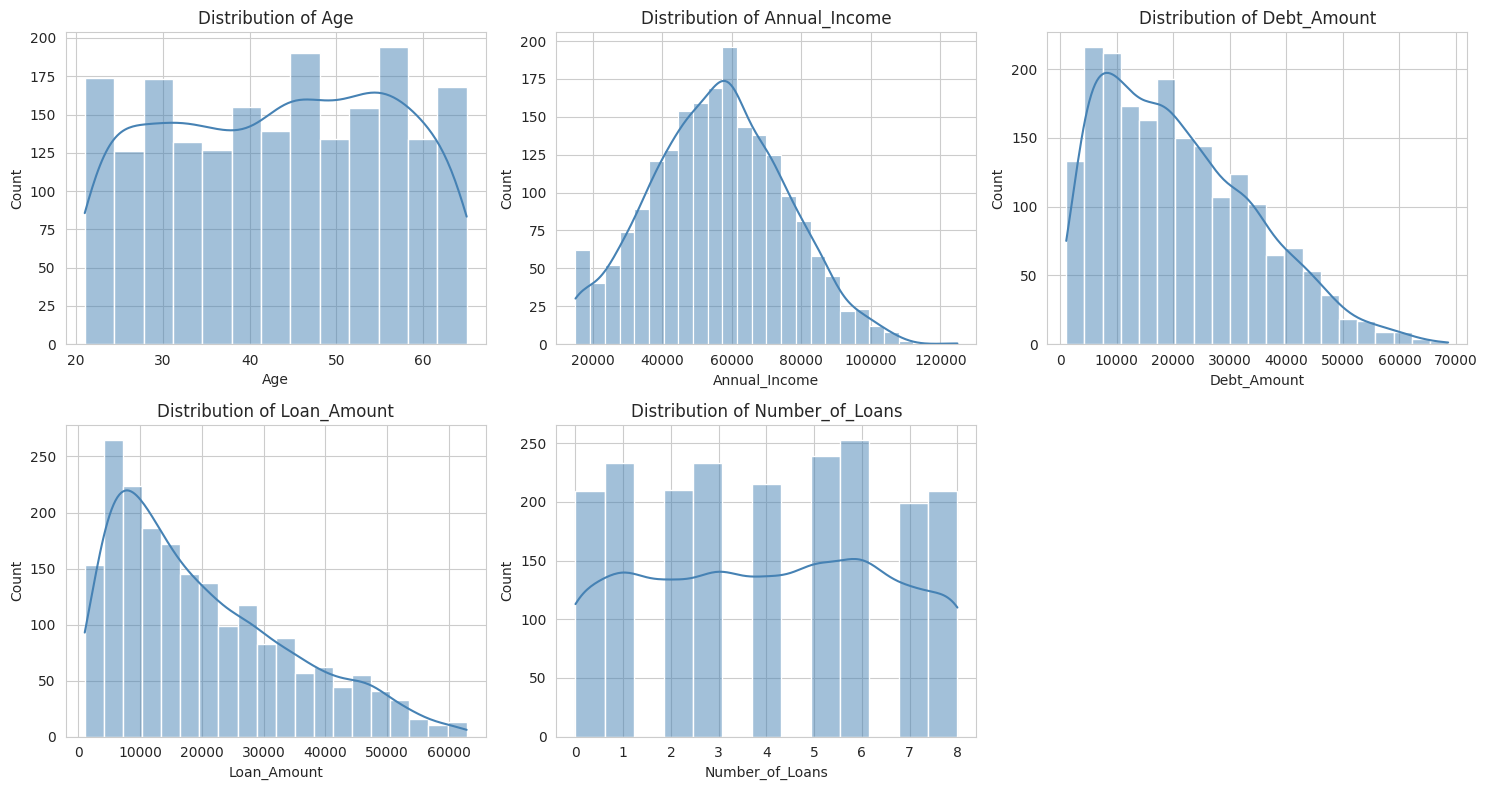

In [10]:
numerical_features = ["Age", "Annual_Income", "Debt_Amount", "Loan_Amount", "Number_of_Loans"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(numerical_features):
    sns.histplot(df[col], kde=True, ax=axes[i], color="steelblue")
    axes[i].set_title(f"Distribution of {col}")

axes[-1].axis("off")  # hide the unused 6th subplot

plt.tight_layout()
plt.savefig("../images/numerical_distributions.png", dpi=120, bbox_inches="tight")
plt.show()


## 6. Categorical Feature Distribution

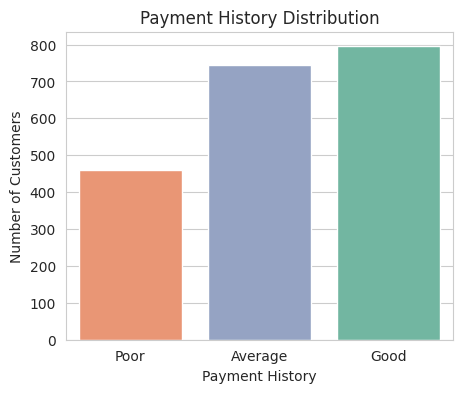

In [11]:
plt.figure(figsize=(5, 4))
sns.countplot(data=df, x="Payment_History", order=["Poor", "Average", "Good"],
              hue="Payment_History", palette="Set2", legend=False)
plt.title("Payment History Distribution")
plt.xlabel("Payment History")
plt.ylabel("Number of Customers")
plt.savefig("../images/payment_history_distribution.png", dpi=120, bbox_inches="tight")
plt.show()


## 7. Box Plots: Numerical Features vs. Credit Risk\n\nBox plots help us see how the spread and median of each numerical feature differ between Good and Bad credit risk customers, and reveal outliers.

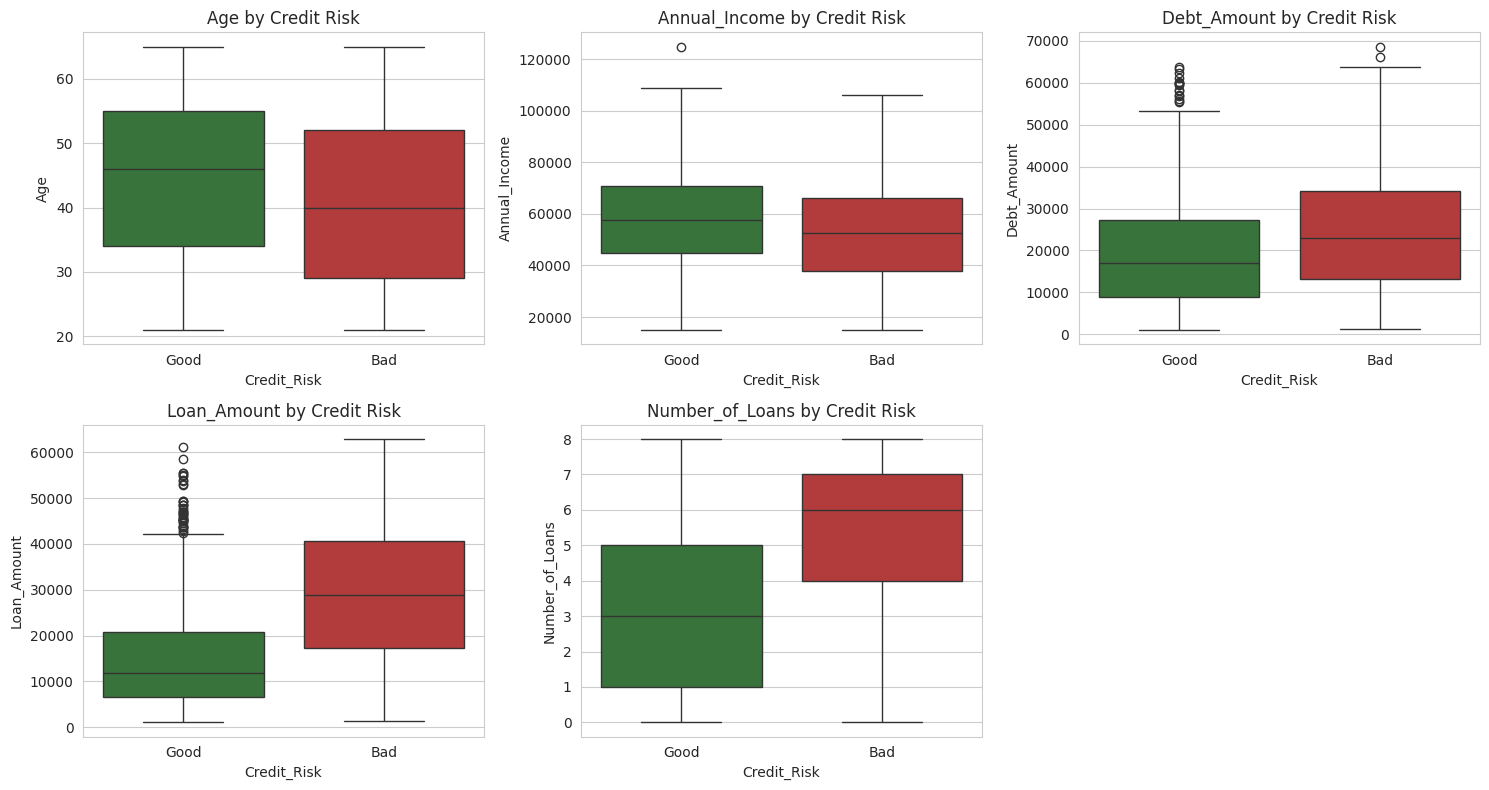

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(numerical_features):
    sns.boxplot(data=df, x="Credit_Risk", y=col, ax=axes[i],
                hue="Credit_Risk", palette={"Good": "#2E7D32", "Bad": "#C62828"}, legend=False)
    axes[i].set_title(f"{col} by Credit Risk")

axes[-1].axis("off")
plt.tight_layout()
plt.savefig("../images/boxplots_by_target.png", dpi=120, bbox_inches="tight")
plt.show()


## 8. Correlation Heatmap

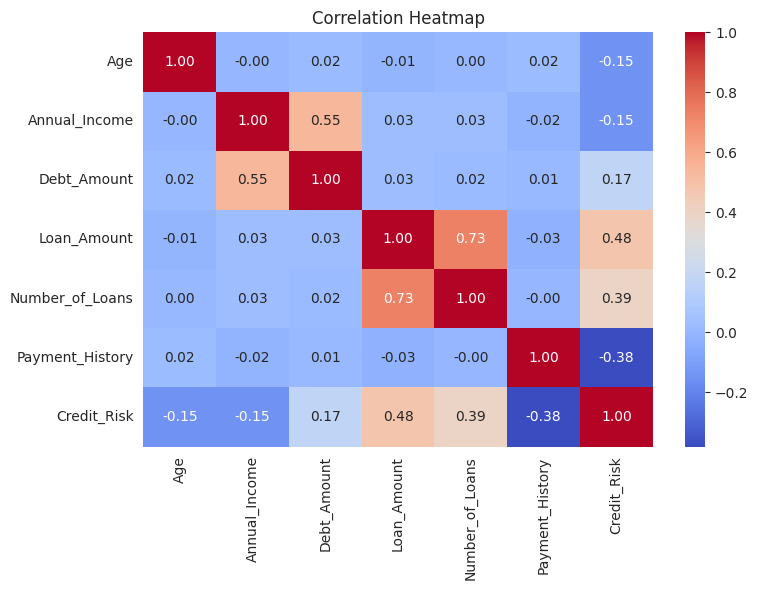

In [13]:
# Correlation only works on numeric data, so we temporarily encode the
# categorical columns just for this visualization (the real encoding
# used for modeling happens later, in train_model.py).
df_corr = df.copy()
df_corr["Payment_History"] = df_corr["Payment_History"].map({"Poor": 0, "Average": 1, "Good": 2})
df_corr["Credit_Risk"] = df_corr["Credit_Risk"].map({"Good": 0, "Bad": 1})

plt.figure(figsize=(8, 6))
sns.heatmap(df_corr.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig("../images/correlation_heatmap.png", dpi=120, bbox_inches="tight")
plt.show()


## 9. Summary of EDA Insights

- The dataset is moderately **imbalanced** (roughly 65% Good vs. 35% Bad), which is realistic for credit risk data.
- Customers with a **Poor** payment history are noticeably more likely to fall into the **Bad (High Risk)** category.
- **Loan_Amount**, **Debt_Amount**, and **Annual_Income** show the strongest relationships with credit risk in the correlation heatmap.
- A small number of missing values and duplicate rows were found and cleaned before analysis - a normal part of working with real-world data.
- The numerical features sit on very different scales (e.g., `Age` vs. `Annual_Income`), so feature scaling will matter when training models such as Logistic Regression.

**Next step:** open `train_model.py` to see how this cleaned data is encoded, split, scaled, and used to train and compare three classification models.
